# Using Neural Networks (subword-level tokenization)

Twin of `main.ipynb` — same tiny MLP, same data, same training loop — but tokens are
**subwords** (byte-level BPE merges, GPT-2 style) instead of single characters.

What changes vs. character-level:
- vocab is learned (BPE merges of frequent pairs) instead of the 65 sorted characters
- the same 1M-char corpus becomes ~2x fewer tokens (here ~1.9 chars/token), so a
  16-token context covers ~31 characters vs the 5-character character context
- the output head predicts the next *token*, and decoding must round-trip bytes -> text

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import os
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

torch.manual_seed(42)

# ------------------------------------------------------------
# 1. Download data (Tiny Shakespeare – classic starter dataset)
# ------------------------------------------------------------

In [ ]:
# !wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O input.txt

with open("../dataset/input.txt", "r", encoding="utf-8") as f: # Replace with your dataset path
    text = f.read()

print(f"Dataset length: {len(text):,} characters")
print("First 300 chars:\n", text[:300])
print("-" * 60)

Dataset length: 1,115,393 characters
First 300 chars:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us
------------------------------------------------------------


# ------------------------------------------------------------
# 2. Subword-level: train a byte-level BPE tokenizer on the corpus
# ------------------------------------------------------------

Byte-level BPE (GPT-2 style):
- `pre_tokenizers.ByteLevel` maps every possible byte (all 256) to a printable
  character, so *any* string can be tokenized - no `<unk>` fallback needed
- `BpeTrainer` learns merge rules: the most frequent pair of adjacent tokens gets
  merged into one new token, building up from single bytes to subwords/words
- `decoders.ByteLevel` reverses the byte mapping so `decode(ids) == original text`

The pre-tokenizer and decoder must be set BEFORE training, so the merges are
learned over the byte representation.

In [9]:
VOCAB_SIZE = 512

tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()

tokenizer.train_from_iterator(
    [text],
    trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE,
        # guarantee all 256 byte-tokens exist before merges start
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    ),
)

vocab_size_bpe = tokenizer.get_vocab_size()
bpe_ids = tokenizer.encode(text).ids

print(f"BPE vocab size: {vocab_size_bpe}")
print(f"BPE sequence length: {len(bpe_ids):,}")
print(f"Compression vs characters: {len(text) / len(bpe_ids):.2f} chars/token")
print()
print("Sample subwords of the first sentence:")
print(tokenizer.encode(text[:100]).tokens)
print()
# round-trip sanity check: decode(encode(x)) must give x back
sample = text[10000:10300]
assert tokenizer.decode(tokenizer.encode(sample).ids) == sample
print("Round-trip decode(encode(x)) == x: OK")

BPE vocab size: 512
BPE sequence length: 575,344
Compression vs characters: 1.94 chars/token

Sample subwords of the first sentence:
['F', 'ir', 'st', 'ĠC', 'it', 'i', 'z', 'en', ':', 'Ċ', 'B', 'e', 'f', 'ore', 'Ġwe', 'Ġp', 'ro', 'ce', 'ed', 'Ġan', 'y', 'Ġf', 'ur', 't', 'her', ',', 'Ġhe', 'ar', 'Ġme', 'Ġsp', 'ea', 'k', '.', 'Ċ', 'Ċ', 'A', 'll', ':', 'Ċ', 'S', 'p', 'ea', 'k', ',', 'Ġsp', 'ea', 'k', '.', 'Ċ', 'Ċ', 'F', 'ir', 'st', 'ĠC', 'it', 'i', 'z', 'en', ':', 'Ċ', 'Y', 'ou']

Round-trip decode(encode(x)) == x: OK


# ------------------------------------------------------------
# 3. Prepare data for MLP training
# ------------------------------------------------------------

Same `create_dataset` as the character notebook: slide a window of `seq_length`
tokens over the corpus; the label is the token that follows. With subwords each
step covers much more *text* (compression printed above), so we keep the token
context longer than the character version's 5.

In [10]:
def create_dataset(data, seq_length):
    """Create input-output pairs for training the MLP."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.tensor(y)

seq_length = 16  # tokens of context (~55 chars of text at this compression)
bpe_data = torch.tensor(bpe_ids, dtype=torch.long)
X, y = create_dataset(bpe_data, seq_length)
print(f"Dataset created with {X.size(0):,} samples.")
print(f"Sample input sequence (indices): {X[-5:-1]}")

Dataset created with 575,328 samples.
Sample input sequence (indices): tensor([[511,  26, 263, 262,  74, 320,  83, 198,  54, 372,  75, 278, 342, 258,
          81,  83],
        [ 26, 263, 262,  74, 320,  83, 198,  54, 372,  75, 278, 342, 258,  81,
          83, 263],
        [263, 262,  74, 320,  83, 198,  54, 372,  75, 278, 342, 258,  81,  83,
         263,  64],
        [262,  74, 320,  83, 198,  54, 372,  75, 278, 342, 258,  81,  83, 263,
          64,  74]])


# ------------------------------------------------------------
# 4. Define the MLP model
# ------------------------------------------------------------

Identical `SimpleMLP` to the character notebook. The only difference is the
input/output width, which now depends on the learned vocab size. One-hot
inputs get wide fast with bigger vocabularies - real models use an embedding
layer instead, which is exactly what the one-hot x Linear trick is a first
step towards.

In [11]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ------------------------------------------------------------
# 5. Train the MLP model
# ------------------------------------------------------------

Same `train_model` as the character notebook - only the `num_classes` for the
one-hot encoding changes to the BPE vocab size.

In [12]:
def train_model(model, X, y, epochs=10, learning_rate=0.001, batch_size=1024):
    """Train with shuffled mini-batches: many gradient steps per epoch."""
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    loss_history = []
    n = X.size(0)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss, steps = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X[idx], y[idx]

            # One-hot encode the input and flatten for the MLP
            one_hot_xb = F.one_hot(xb, num_classes=vocab_size_bpe).float().view(xb.size(0), -1)

            optimizer.zero_grad()
            output = model(one_hot_xb)
            loss = loss_fn(output, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            steps += 1

        loss_history.append(epoch_loss / steps)
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss / steps:.4f}")

    return loss_history

# ------------------------------------------------------------
# 6. Experiment with different learning rates and model sizes
# ------------------------------------------------------------

Note the trade-off vs. the character model:
- input is `vocab_size_bpe * seq_length` wide (512 * 16 = 8192 vs 65 * 5 = 325)
- hidden size is raised to 512 to give the wider input more capacity
- but the output head is only 512-way (vs 65-way), and each sample covers ~2x
  more text, so there are ~2x fewer training samples for the same corpus

torch.Size([1, 512])
Epoch [1/10], Loss: 4.7076
Epoch [2/10], Loss: 3.3947
Epoch [3/10], Loss: 2.9987
Epoch [4/10], Loss: 2.8054
Epoch [5/10], Loss: 2.6695
Epoch [6/10], Loss: 2.5603
Epoch [7/10], Loss: 2.4666
Epoch [8/10], Loss: 2.3819
Epoch [9/10], Loss: 2.3052
Epoch [10/10], Loss: 2.2338


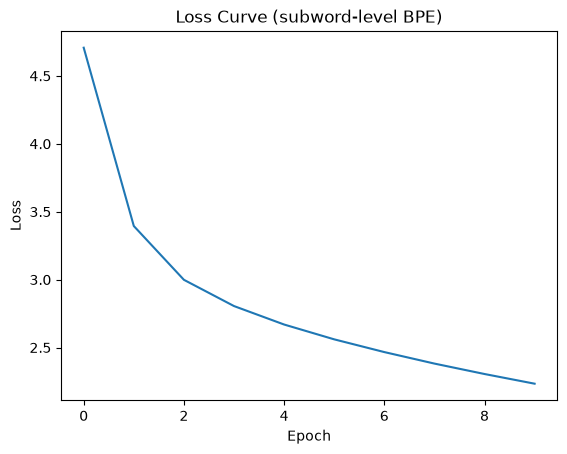

In [13]:
hidden_size = 512  # raised vs. the character model: the input is much wider now
model = SimpleMLP(input_size=vocab_size_bpe * seq_length, output_size=vocab_size_bpe, hidden_size=hidden_size)
print(model(torch.zeros(1, vocab_size_bpe * seq_length)).shape)

loss_history = train_model(model, X, y, epochs=10, learning_rate=0.001, batch_size=4096)

# Plotting the loss curve
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Loss Curve (subword-level BPE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ------------------------------------------------------------
# 7. Generate text using the trained MLP
# ------------------------------------------------------------

Differences from the character version:
- contexts are built from *tokens*, so padding uses the newline token id instead
  of a `'\n'` character (real line starts in the corpus begin with newlines)
- the sampled token is appended to the token stream and decoded with the BPE
  `ByteLevel` decoder, which reverses the byte mapping exactly
- losses across the two notebooks are NOT directly comparable (65-way vs 512-way
  cross-entropy); compare the *generated text quality* instead

In [14]:
# Byte-level BPE stores '\n' as its byte-mapped character in the vocab, so look
# it up by encoding the newline string itself (always a single-byte token).
newline_id = tokenizer.encode("\n").ids[0]


def generate_text(model, start_str, length=100, temperature=0.8):
    model.eval()

    if len(start_str) == 0:
        raise ValueError("start_str must not be empty")

    # Tokens of the prompt. With byte-level BPE every string encodes to some
    # token id, so there is no <unk> case to validate against.
    generated = tokenizer.encode(start_str).ids

    # Ensure the model always receives seq_length tokens. Pad with the newline
    # token (line starts), not spaces: padded contexts then look like real line
    # beginnings from the training data.
    context = generated[-seq_length:]
    context = [newline_id] * (seq_length - len(context)) + context
    input_seq = torch.tensor([context], dtype=torch.long)

    for _ in range(length):
        one_hot_input = F.one_hot(
            input_seq,
            num_classes=vocab_size_bpe
        ).float().view(1, -1)

        with torch.no_grad():
            output = model(one_hot_input)

        # Sample from the probability distribution instead of taking the
        # argmax: greedy decoding is deterministic, so once a context repeats,
        # the model falls into an endless loop.
        probs = F.softmax(output / temperature, dim=1)
        next_token_id = torch.multinomial(probs, num_samples=1).item()
        generated.append(next_token_id)

        input_seq = torch.cat(
            (input_seq[:, 1:], torch.tensor([[next_token_id]])),
            dim=1
        )

    # ByteLevel decoder reverses the byte mapping exactly: decode(ids) == text
    return tokenizer.decode(generated)


generated_text = generate_text(model, start_str="First Citizen:", length=300, temperature=0.8)
print("Generated text:\n", generated_text)

Generated text:
 First Citizen: and where you, way with me,
My dinns are come to dis, but myself, and down.

IDAKEBHow now, for betom, and I will not.

LUCENTIO:
I have made you, sir? what your speak?

Provost:
I am so grave to idleward.

GRUMIO:
O, thou shalt depoint thou gall'd
Mine home, cry 'blike, find!' ne' poor to.

LADY GREY:
'Tis weal neger, honour, sir; is trumpers;
Hilt thou hast how?

JULIET:
What, is head? O's head?

BRAKABUnard: I have grought it is my house,
To make my poins you pre of my liege?

ELAO:
A aditt, thank I for want for gue.

QUEEN ELIZABETH:
